# UNSW-NB15 — Descriptive Statistical Analysis (Presentation Notes)

This notebook performs **descriptive statistics** (exploration + visualization) on the **UNSW-NB15 testing dataset**.

**Goal (what to say in class):**
- Understand the dataset structure (rows/columns, types, missing values).
- Compare **Normal vs Attack** traffic using the `label` column (0=Normal, 1=Attack).
- Explore **attack categories**, **protocol usage**, and distributions of key numeric features like `dur` (duration) and `rate`.
- Handle extreme values using the **IQR outlier rule** to make statistics/plots more representative.

**Important columns used here:**
- `label`: binary class (0 normal, 1 attack)
- `attack_cat`: type of attack (e.g., Generic, Exploits, …)
- `proto`: protocol (tcp/udp/…)
- `dur`: connection duration
- `rate`: traffic rate feature


In [8]:
# =========================
# 0) Libraries (Python basics)
# =========================
# pandas  : read CSV + manipulate tables (DataFrame)
# matplotlib/seaborn : plots for exploration
# numpy   : numeric helper functions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np


In [13]:
# =========================
# 1) Load the dataset
# =========================
# The file must be in the same folder as this notebook (or provide a full path).
# read_csv -> DataFrame (table-like structure: rows = records, columns = features)
df = pd.read_csv('UNSW_NB15_testing-set.csv')

# Quick look at the first rows to confirm successful loading
df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,Normal,0.0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,Normal,0.0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1.0,3.0,0.0,0.0,0.0,1.0,3.0,0.0,Normal,0.0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1.0,3.0,0.0,0.0,0.0,2.0,3.0,0.0,Normal,0.0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1.0,3.0,0.0,0.0,0.0,2.0,3.0,0.0,Normal,0.0


In [ ]:
# =========================
# 2) Missing values check
# =========================
# isnull() gives True where value is missing (NaN). sum() counts missing per column.
# If many missing values existed, we would decide how to handle them (drop/impute).
df.isnull().sum()


,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [ ]:
# =========================
# 3) Basic exploration
# =========================
# shape  -> (number_of_rows, number_of_columns)
# info() -> column names + data types + non-null counts
# describe() -> summary statistics for numeric columns (count, mean, std, min, quartiles, max)
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


# **Target analysis (Normal vs Attack)**

In [ ]:
# =========================
# 4) Target analysis: Normal vs Attack
# =========================
# label = 0 -> Normal traffic
# label = 1 -> Attack traffic
# value_counts() counts how many rows belong to each class.
df['label'].value_counts()


,count
label,
1,45332
0,37000


In [ ]:
# Visualize the class distribution (bar chart)
df['label'].value_counts().plot(kind='bar')
plt.title('Normal vs Attack Traffic')
plt.xlabel('label (0=Normal, 1=Attack)')
plt.ylabel('count')
plt.show()


# **Attack categories**

In [ ]:
# =========================
# 5) Attack categories
# =========================
# attack_cat is a categorical feature describing the attack family.
# We count how many samples belong to each category.
df['attack_cat'].value_counts()


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


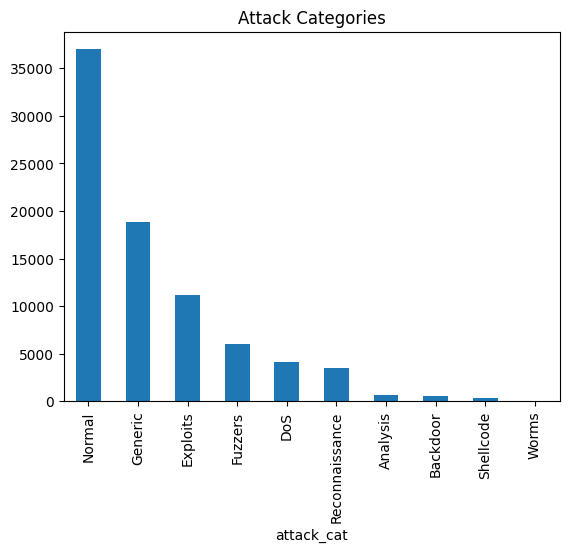

In [ ]:
# Bar chart: frequency of each attack category
df['attack_cat'].value_counts().plot(kind='bar')
plt.title('Attack Categories')
plt.xlabel('attack_cat')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# **Descriptive plots**

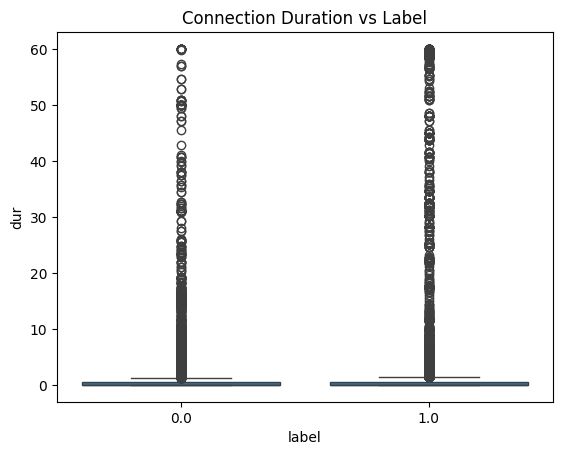

In [ ]:
# =========================
# 6) Descriptive plots (compare distributions)
# =========================
# Boxplot shows median + quartiles + possible outliers.
# Here we compare connection duration (dur) between normal and attack traffic.
sns.boxplot(x='label', y='dur', data=df)
plt.title('Connection Duration (dur) vs Label')
plt.xlabel('label (0=Normal, 1=Attack)')
plt.ylabel('dur (seconds)')
plt.show()


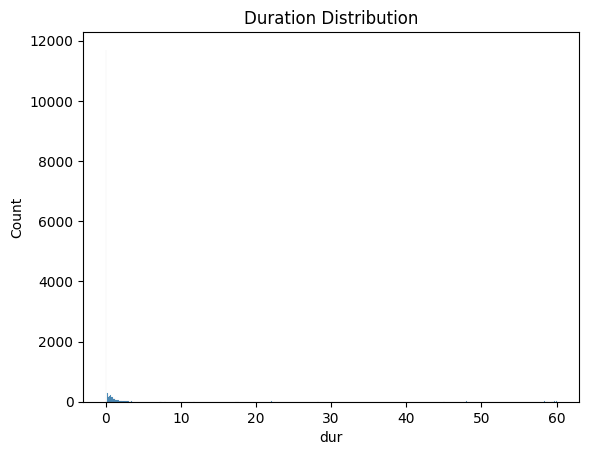

In [15]:
# Histogram: distribution of connection duration
# If the distribution is heavily skewed, a log scale can help (optional).
sns.histplot(df['dur'])
plt.title('Duration (dur) Distribution')
plt.xlabel('dur')
plt.ylabel('count')
plt.show()


# **Protocol analysis**

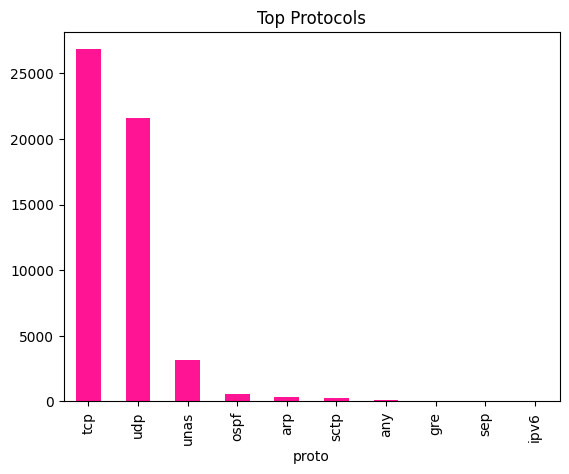

In [ ]:
# =========================
# 7) Protocol analysis
# =========================
# proto = protocol used by the connection (e.g., tcp/udp/icmp/...)
# value_counts() shows which protocols are most frequent.
top_proto = df['proto'].value_counts().head(10)

top_proto.plot(kind='bar', color=mcolors.CSS4_COLORS['deeppink'])
plt.title('Top 10 Protocols (proto)')
plt.xlabel('protocol')
plt.ylabel('count')
plt.tight_layout()
plt.show()


# **Outlier Detection (IQR method)**

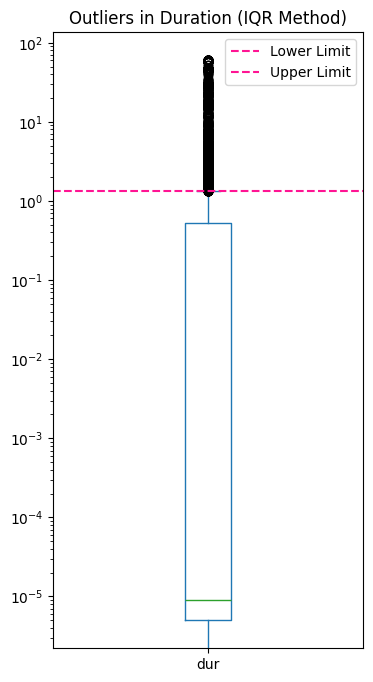

In [16]:
# =========================
# 8) Outlier detection for 'dur' using the IQR method
# =========================
# Why? Some durations can be extremely large (outliers), which can distort the mean.
# IQR rule:
#   Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1
#   Lower bound = Q1 - 1.5*IQR
#   Upper bound = Q3 + 1.5*IQR

# Ensure 'dur' is numeric (errors -> NaN)
df['dur'] = pd.to_numeric(df['dur'], errors='coerce')

# Compute quartiles and IQR
Q1 = df['dur'].quantile(0.25)
Q3 = df['dur'].quantile(0.75)
IQR = Q3 - Q1

# Outlier limits
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Boxplot (log scale makes extreme skew readable)
plt.figure(figsize=(4, 8))
df['dur'].plot.box()
plt.yscale('log')

# Draw the limits on the plot
plt.axhline(lim_inf, color='deeppink', linestyle='--', label='Lower Limit')
plt.axhline(lim_sup, color='deeppink', linestyle='--', label='Upper Limit')

plt.title('Outliers in Duration (IQR Method)')
plt.legend()
plt.show()


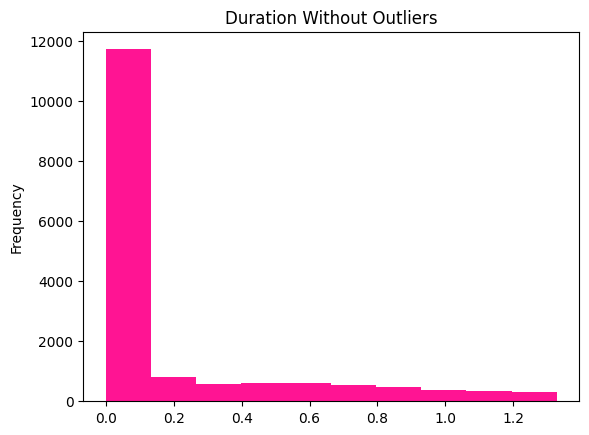

In [17]:
# Remove outliers using the IQR limits
# Keep only rows where dur is inside [lim_inf, lim_sup]
df_filtered = df[(df['dur'] >= lim_inf) & (df['dur'] <= lim_sup)]

# Compare number of records before vs after filtering
len(df), len(df_filtered)

# Plot duration distribution after removing outliers
df_filtered['dur'].plot.hist(color='deeppink')
plt.title('Duration (dur) Without Outliers')
plt.xlabel('dur')
plt.ylabel('count')
plt.show()


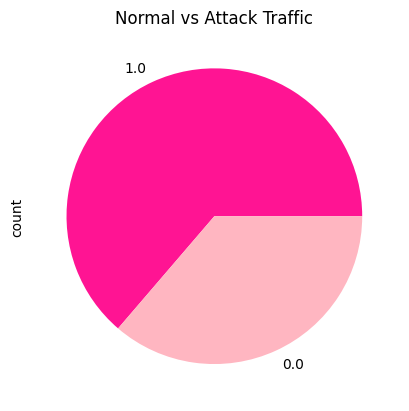

In [ ]:
# =========================
# 9) Visual summary: share of Normal vs Attack traffic
# =========================
# Pie chart for class proportions.
df['label'].value_counts().plot.pie(colors=['deeppink', 'lightpink'], autopct='%1.1f%%')
plt.title('Normal vs Attack Traffic (Proportion)')
plt.ylabel('')  # hide y-label
plt.show()


In [19]:
# Percentage form (more readable than raw counts)
attack_percent = df['label'].value_counts(normalize=True) * 100
attack_percent


,proportion
label,
1.0,98.668347
0.0,1.331653


In [20]:
# Mean duration per class (note: mean can be affected by outliers)
df.groupby('label')['dur'].mean()


,dur
label,
0.0,9.998703
1.0,1.067623


In [ ]:
# Mean rate per class
df.groupby('label')['rate'].mean()


,rate
label,
0.0,8730.569864
1.0,130187.482072


In [21]:
# Most common attack category (top 1)
df['attack_cat'].value_counts().head(1)


,count
attack_cat,
Generic,6237


In [ ]:
# Protocols most frequently used during attacks only (label==1)
df[df['label'] == 1]['proto'].value_counts().head()


,count
proto,
udp,16303
tcp,11987
unas,3160
ospf,559
sctp,272


In [ ]:
# Median duration per class (robust to outliers)
df.groupby('label')['dur'].median()


,dur
label,
0.0,0.030132
1.0,0.000009


In [ ]:
# Overall median duration across all records
df['dur'].median()


0.004209

In [22]:
# Top 10 'service' values among attacks only (label==1)
# service ~ application/service type (e.g., http, dns, ...)
df[df['label'] == 1]['service'].value_counts().head(10)


,count
service,
-,8046
dns,6220
http,2287
smtp,612
ftp,321
ftp-data,254
pop3,217
dhcp,17
snmp,15


In [23]:
# Top 10 'state' values among attacks only (label==1)
# state ~ connection state feature in the dataset
df[df['label'] == 1]['state'].value_counts().head(10)


,count
state,
INT,12072
FIN,5695
CON,158
REQ,79
ACC,1


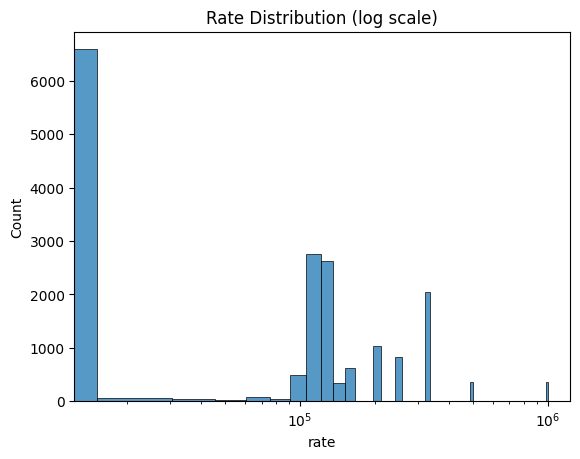

In [24]:
# =========================
# 10) Distribution of 'rate'
# =========================
# rate can have a very wide range. Using log scale makes the plot readable.
sns.histplot(df['rate'])
plt.xscale('log')  # log scale -> multiplicative steps (10x, 100x, ...)
plt.title('Rate Distribution (log scale)')
plt.xlabel('rate')
plt.ylabel('count')
plt.show()


---

## Quick presentation script (30–45 seconds)

1) “I loaded the UNSW-NB15 testing dataset into a pandas DataFrame and checked missing values and column types.”  
2) “I analyzed the target `label` to compare normal vs attack traffic, then explored `attack_cat` to see which attack families are most common.”  
3) “I used descriptive statistics and plots for numeric features like `dur` and `rate`.”  
4) “Because `dur` contains extreme values, I used the IQR method to detect/remove outliers so the plots and averages are more representative.”  
5) “Finally, I checked which protocols and services appear most during attacks.”

## Teacher “basic Python” questions you can answer
- What is a DataFrame? (table with rows/columns)
- What does `read_csv` do?
- What does `value_counts()` return?
- What does `groupby('label')` mean?
- Mean vs median (outliers)
- What is IQR and the 1.5× rule?
